In [ ]:
!pip install roboflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.6/94.6 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="kCCeMleCltWO2NHMo5Z4")
project = rf.workspace("roboflow-universe-projects").project("personal-protective-equipment-combined-model")
version = project.version(8)
dataset = version.download("yolov8")

/content/Personal-Protective-Equipment---Combined-Model-8


In [ ]:
import yaml

with open(dataset.location + "/data.yaml", "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]

print("Số class:", len(class_names))
print("Danh sách class:", class_names)

Số class: 14
Danh sách class: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


ValueError: num must be an integer with 1 <= num <= 4, not 5

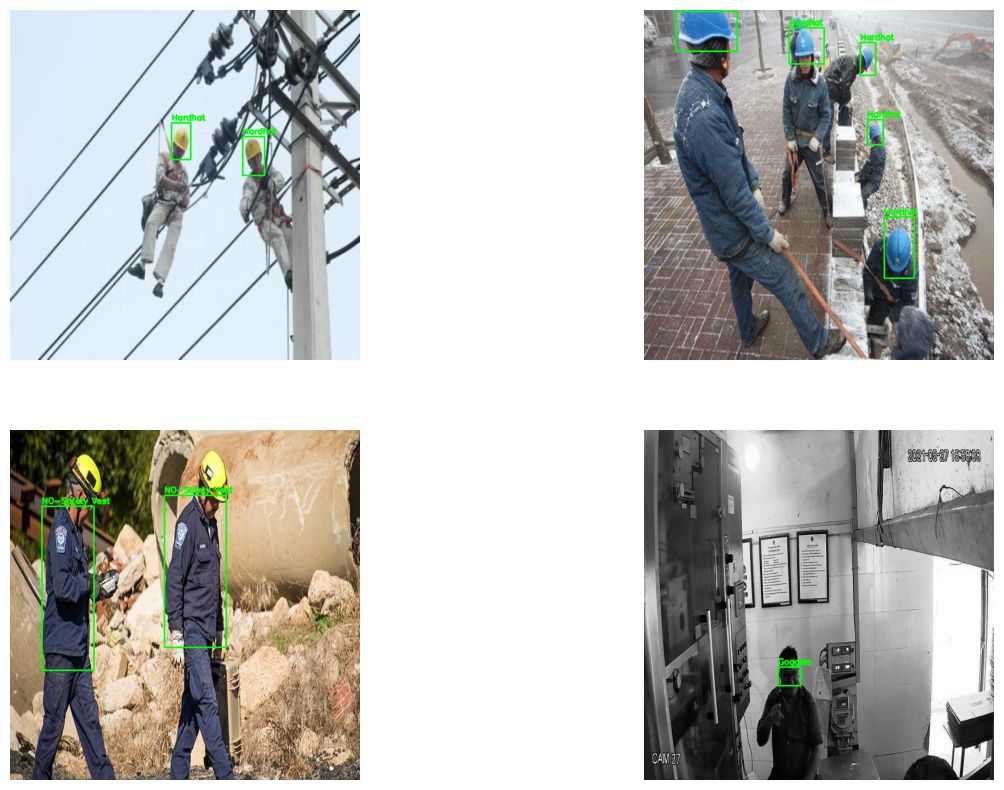

In [ ]:
import os
import cv2
import random
import matplotlib.pyplot as plt

images_dir = os.path.join(dataset.location, "train/images")
labels_dir = os.path.join(dataset.location, "train/labels")

image_files = os.listdir(images_dir)

def show_random_images(n=4):
    plt.figure(figsize=(15, 10))

    for i in range(n):
        img_file = random.choice(image_files)
        img_path = os.path.join(images_dir, img_file)
        label_path = os.path.join(labels_dir, img_file.replace(".jpg", ".txt"))

        img = cv2.imread(img_path)
        h, w, _ = img.shape

        if os.path.exists(label_path):
            with open(label_path) as f:
                lines = f.readlines()

            for line in lines:
                cls, x, y, bw, bh = map(float, line.split())

                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)

                label = class_names[int(cls)]

                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img, label, (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.5, (0,255,0), 2)

        plt.subplot(2, 2, i+1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(12)

In [ ]:
from collections import Counter

counter = Counter()

for file in os.listdir(labels_dir):
    with open(os.path.join(labels_dir, file)) as f:
        for line in f:
            cls = int(line.split()[0])
            counter[class_names[cls]] += 1

print(counter)

Counter({'Hardhat': 28996, 'Safety Cone': 9843, 'NO-Hardhat': 9705, 'Safety Vest': 4499, 'NO-Gloves': 4280, 'Gloves': 3381, 'Fall-Detected': 3149, 'Goggles': 2959, 'NO-Goggles': 2817, 'Mask': 1989, 'NO-Mask': 1577, 'NO-Safety Vest': 1435, 'Person': 1034, 'Ladder': 734})


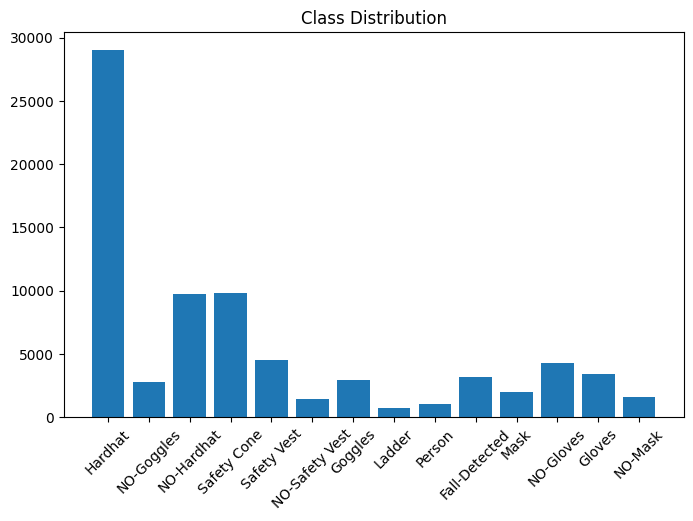

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(counter.keys(), counter.values())
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [ ]:
from roboflow import Roboflow

rf = Roboflow(api_key="kCCeMleCltWO2NHMo5Z4")
project = rf.workspace("roboflow-universe-projects").project("personal-protective-equipment-combined-model")
version = project.version(8)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...


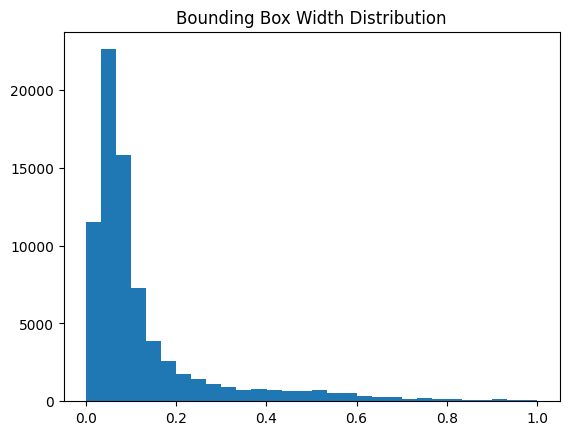

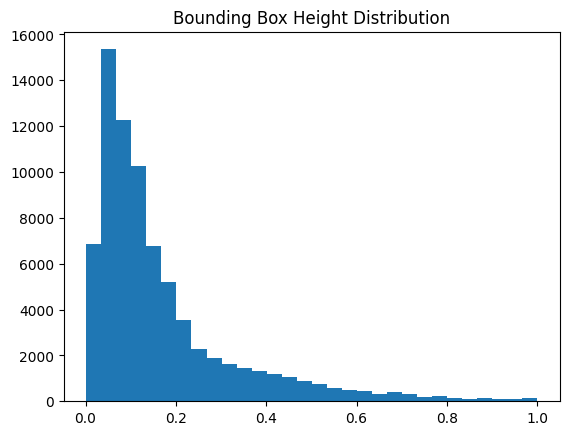

In [ ]:
widths = []
heights = []

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            widths.append(float(parts[3]))
            heights.append(float(parts[4]))

plt.figure()
plt.hist(widths, bins=30)
plt.title("Bounding Box Width Distribution")
plt.show()

plt.figure()
plt.hist(heights, bins=30)
plt.title("Bounding Box Height Distribution")
plt.show()

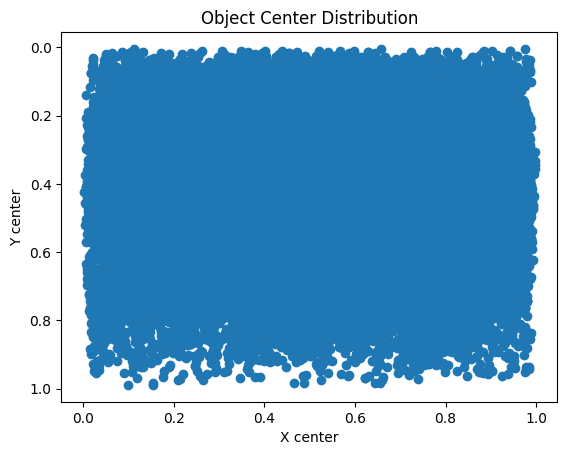

In [ ]:
x_centers = []
y_centers = []

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            parts = line.split()
            x_centers.append(float(parts[1]))
            y_centers.append(float(parts[2]))

plt.figure()
plt.scatter(x_centers, y_centers)
plt.gca().invert_yaxis()
plt.title("Object Center Distribution")
plt.xlabel("X center")
plt.ylabel("Y center")
plt.show()

In [ ]:
print(dataset.location)

/content/Personal-Protective-Equipment---Combined-Model-8


In [ ]:
import os
import yaml

DATASET_PATH = "/content/Personal-Protective-Equipment---Combined-Model-8"

with open(os.path.join(DATASET_PATH, "data.yaml"), 'r') as f:
    data_yaml = yaml.safe_load(f)

num_classes = data_yaml["nc"]
class_names = data_yaml["names"]

print("Number of classes:", num_classes)
print("Class names:", class_names)

Number of classes: 14
Class names: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


In [ ]:
def count_images(folder):
    return len(os.listdir(folder))

train_images = count_images(os.path.join(DATASET_PATH, "train/images"))
valid_images = count_images(os.path.join(DATASET_PATH, "valid/images"))
test_images  = count_images(os.path.join(DATASET_PATH, "test/images"))

print("Train:", train_images)
print("Valid:", valid_images)
print("Test:", test_images)

Train: 30765
Valid: 8814
Test: 4423


In [ ]:
import glob
import pandas as pd

label_files = glob.glob(os.path.join(DATASET_PATH, "train/labels/*.txt"))

records = []

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            parts = line.strip().split()
            records.append({
                "image": os.path.basename(file),
                "class_id": int(parts[0]),
                "x_center": float(parts[1]),
                "y_center": float(parts[2]),
                "width": float(parts[3]),
                "height": float(parts[4]),
            })

df = pd.DataFrame(records)
df["class_name"] = df["class_id"].apply(lambda x: class_names[x])
df["area"] = df["width"] * df["height"]
df["aspect_ratio"] = df["width"] / df["height"]

df.head()

,image,class_id,x_center,y_center,width,height,class_name,area,aspect_ratio
0,004177_jpg.rf.f7ab1eda6d6be2b0a60f3b38c03f5050...,3,0.688281,0.300000,0.156250,0.276562,Hardhat,0.043213,0.564972
1,frame439_jpg.rf.ae1b1d24c6f4eccc51788dffb96552...,7,0.690625,0.434375,0.035937,0.023438,NO-Goggles,0.000842,1.533333
2,IMG_3102_mp4-22_jpg.rf.cc45c346e4c23d9974ed37f...,8,0.450781,0.463281,0.489844,0.383594,NO-Hardhat,0.187901,1.276986
3,amz_01881_png_jpg.rf.65de499ce21618add80d15d17...,12,0.478125,0.578125,0.042969,0.167187,Safety Cone,0.007184,0.257009
4,amz_01881_png_jpg.rf.65de499ce21618add80d15d17...,12,0.483594,0.407813,0.022656,0.088281,Safety Cone,0.002000,0.256637


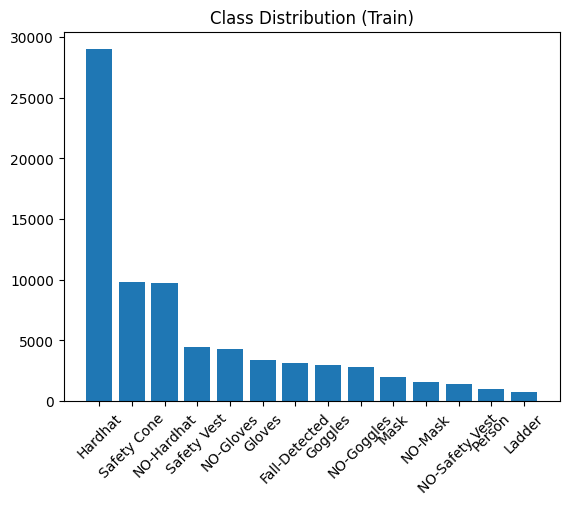

,Count,Percent
class_name,,
Hardhat,28996,37.953873
Safety Cone,9843,12.883845
NO-Hardhat,9705,12.703212
Safety Vest,4499,5.888898
NO-Gloves,4280,5.602241
Gloves,3381,4.425509
Fall-Detected,3149,4.121836
Goggles,2959,3.873138
NO-Goggles,2817,3.687269


In [ ]:
import matplotlib.pyplot as plt

class_dist = df["class_name"].value_counts()
class_percent = 100 * class_dist / class_dist.sum()

plt.figure()
plt.bar(class_dist.index, class_dist.values)
plt.xticks(rotation=45)
plt.title("Class Distribution (Train)")
plt.show()

pd.DataFrame({
    "Count": class_dist,
    "Percent": class_percent
})

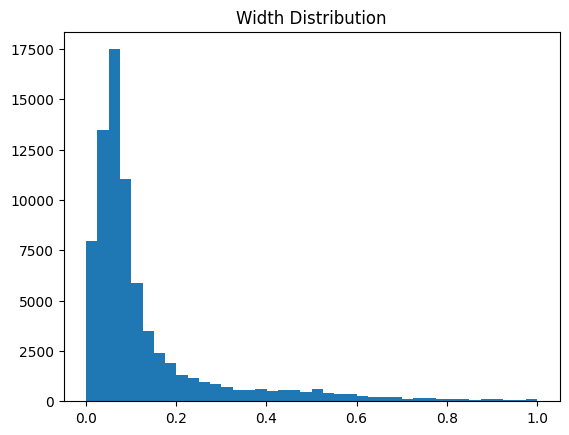

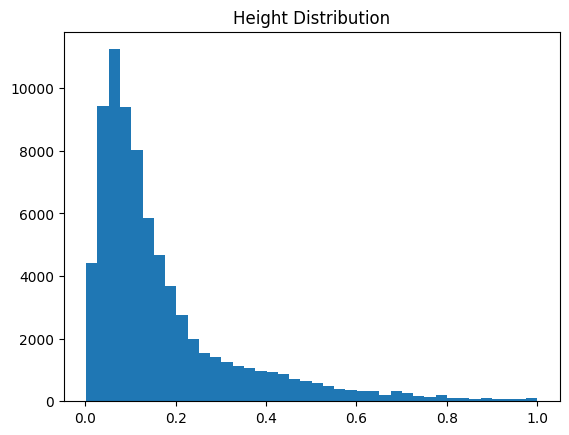

In [ ]:
plt.figure()
plt.hist(df["width"], bins=40)
plt.title("Width Distribution")
plt.show()

plt.figure()
plt.hist(df["height"], bins=40)
plt.title("Height Distribution")
plt.show()

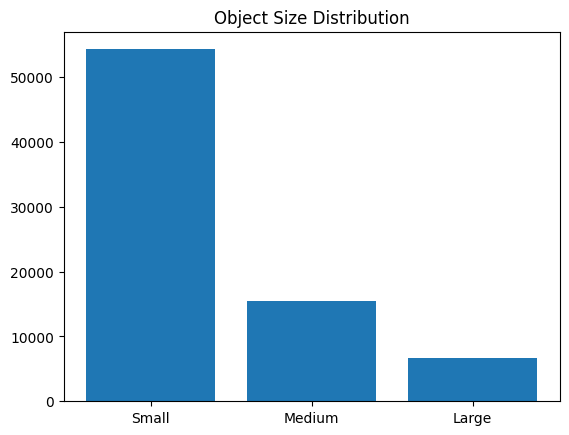

,count
size_category,
Small,54301
Medium,15395
Large,6702


In [ ]:
df["size_category"] = pd.cut(
    df["area"],
    bins=[0, 0.02, 0.15, 1.0],
    labels=["Small", "Medium", "Large"]
)

size_dist = df["size_category"].value_counts()

plt.figure()
plt.bar(size_dist.index.astype(str), size_dist.values)
plt.title("Object Size Distribution")
plt.show()

size_dist

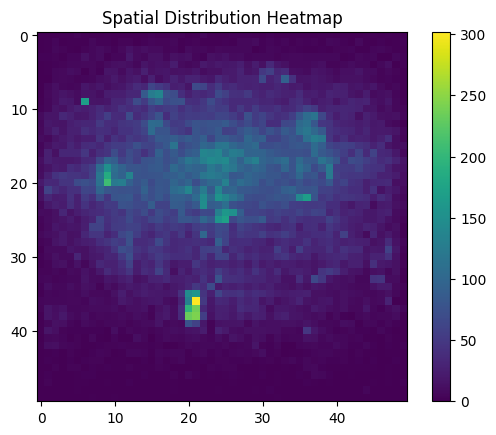

In [ ]:
import numpy as np

heatmap, xedges, yedges = np.histogram2d(
    df["x_center"],
    df["y_center"],
    bins=50
)

plt.figure()
plt.imshow(heatmap.T)
plt.title("Spatial Distribution Heatmap")
plt.colorbar()
plt.show()

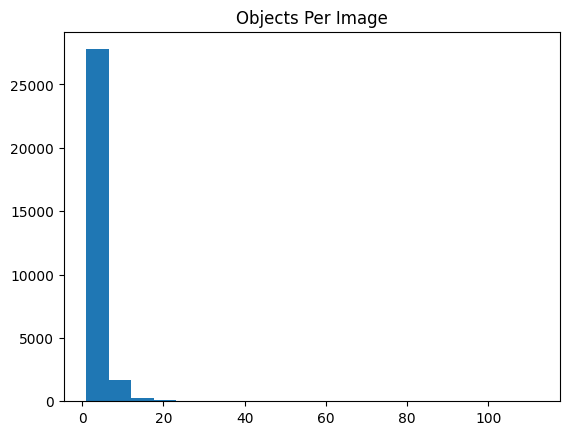

,0
count,29917.000000
mean,2.553665
std,3.552780
min,1.000000
25%,1.000000
50%,1.000000
75%,3.000000
max,112.000000


In [ ]:
objects_per_image = df.groupby("image").size()

plt.figure()
plt.hist(objects_per_image, bins=20)
plt.title("Objects Per Image")
plt.show()

objects_per_image.describe()

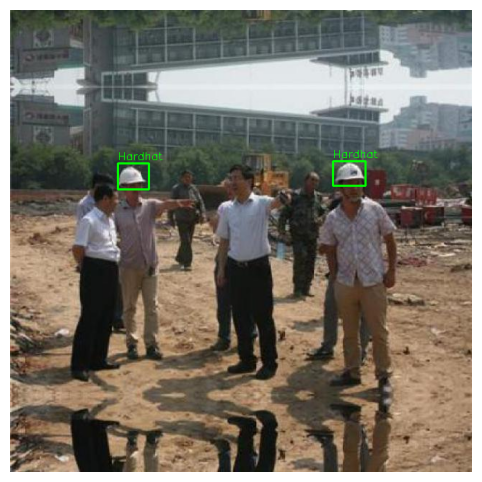

In [ ]:
import cv2
import random

random_label = random.choice(label_files)
image_name = os.path.basename(random_label).replace(".txt", ".jpg")

img_path = os.path.join(DATASET_PATH, "train/images", image_name)
img = cv2.imread(img_path)

h, w, _ = img.shape
sub_df = df[df["image"] == os.path.basename(random_label)]

for _, row in sub_df.iterrows():
    x1 = int((row["x_center"] - row["width"]/2) * w)
    y1 = int((row["y_center"] - row["height"]/2) * h)
    x2 = int((row["x_center"] + row["width"]/2) * w)
    y2 = int((row["y_center"] + row["height"]/2) * h)

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, row["class_name"], (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

In [ ]:
import os
import glob
import yaml
import numpy as np
import pandas as pd

DATASET_PATH = "/content/Personal-Protective-Equipment---Combined-Model-8"

# Load class names
with open(os.path.join(DATASET_PATH, "data.yaml"), 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]

# Load annotations
label_files = glob.glob(os.path.join(DATASET_PATH, "train/labels/*.txt"))

class_counts = {}

for file in label_files:
    with open(file, "r") as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] = class_counts.get(class_id, 0) + 1

# Convert to dataframe
df_counts = pd.DataFrame({
    "class_id": list(class_counts.keys()),
    "count": list(class_counts.values())
})

df_counts["class_name"] = df_counts["class_id"].apply(lambda x: class_names[x])
df_counts = df_counts.sort_values("count", ascending=False)

df_counts

,class_id,count,class_name
0,3,28996,Hardhat
3,12,9843,Safety Cone
2,8,9705,NO-Hardhat
4,13,4499,Safety Vest
11,6,4280,NO-Gloves
12,1,3381,Gloves
9,0,3149,Fall-Detected
6,2,2959,Goggles
1,7,2817,NO-Goggles
10,5,1989,Mask


In [ ]:
max_count = df_counts["count"].max()
min_count = df_counts["count"].min()

imbalance_ratio = max_count / min_count

print("Imbalance Ratio:", imbalance_ratio)

Imbalance Ratio: 39.50408719346049


In [ ]:
counts = df_counts["count"].values
probs = counts / counts.sum()

entropy = -np.sum(probs * np.log(probs))
max_entropy = np.log(len(probs))

normalized_entropy = entropy / max_entropy

print("Shannon Entropy:", entropy)
print("Max Possible Entropy:", max_entropy)
print("Normalized Entropy:", normalized_entropy)

Shannon Entropy: 2.0916866198981734
Max Possible Entropy: 2.6390573296152584
Normalized Entropy: 0.7925885491101154


In [ ]:
gini = 1 - np.sum(probs**2)
print("Gini Index:", gini)

Gini Index: 0.8083580536765322


In [ ]:
mean_count = np.mean(counts)
std_count = np.std(counts)

cv = std_count / mean_count

print("Coefficient of Variation:", cv)

Coefficient of Variation: 1.297299984016245


In [ ]:
effective_classes = np.exp(entropy)

print("Effective Number of Classes:", effective_classes)
print("Actual Number of Classes:", len(counts))

Effective Number of Classes: 8.0985628490893
Actual Number of Classes: 14


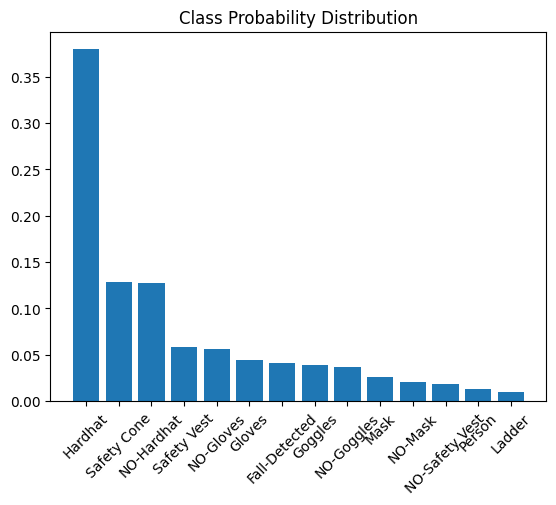

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_counts["class_name"], probs)
plt.xticks(rotation=45)
plt.title("Class Probability Distribution")
plt.show()